In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
from sklearn.metrics import classification_report

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import zipfile

with zipfile.ZipFile("/content/drive/MyDrive/6CS012 - Artificial Intelligence and Machine Learning./Week 5/FruitinAmazon.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

print("Dataset folder extracted successfully!")

Dataset folder extracted successfully!


## Task 1: Data Understanding and Visualization

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


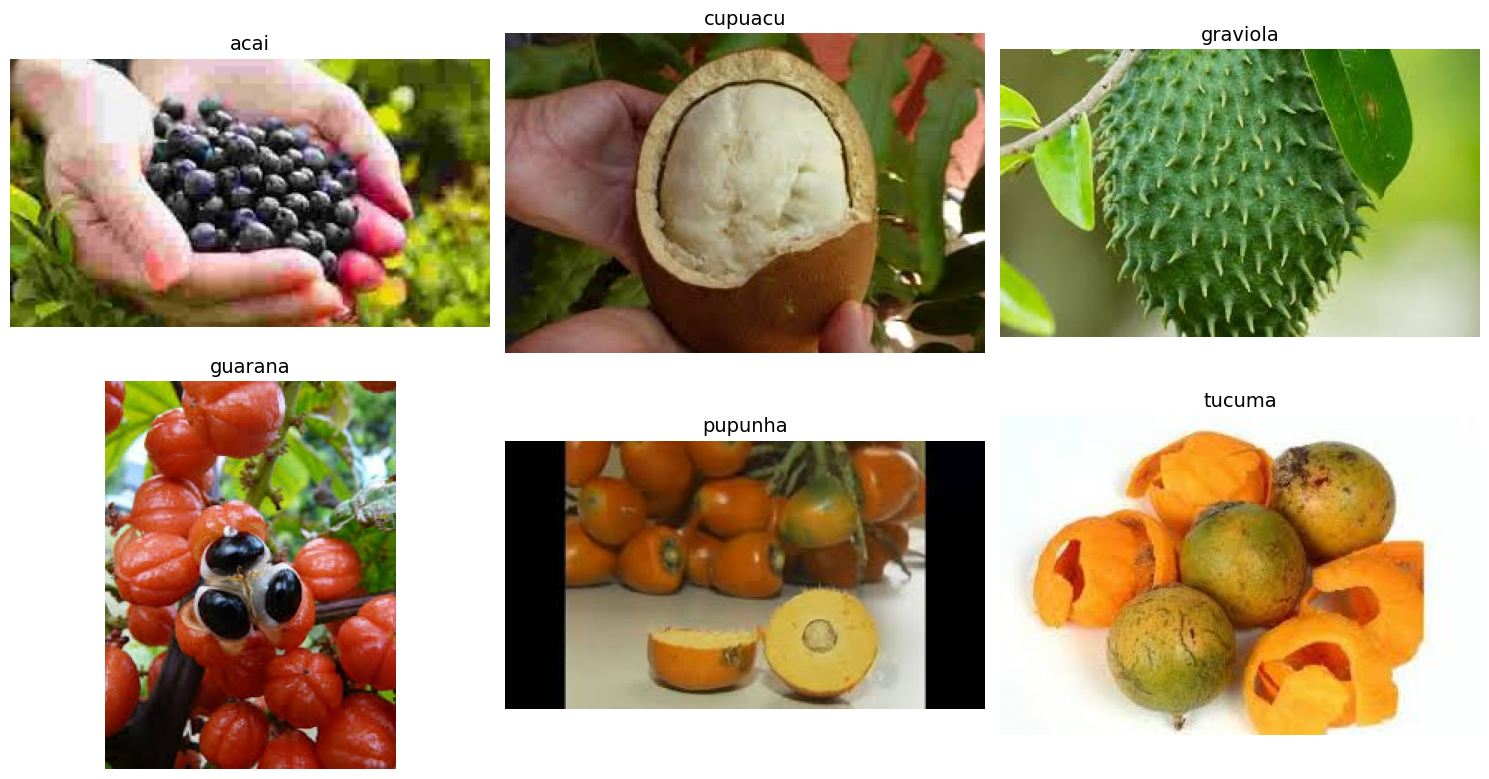

In [6]:
train_dir = 'FruitinAmazon/train'
test_dir = 'FruitinAmazon/test'

# Get the list of class directories from the train folder
class_names = sorted(os.listdir(train_dir))
print(f"Classes found: {class_names}")
print(f"Number of classes: {len(class_names)}")

# Select one image randomly from each class
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        images = [img for img in images if img.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
        if images:
            random_image = random.choice(images)
            image_path = os.path.join(class_path, random_image)
            selected_images.append(image_path)
            selected_labels.append(class_name)

# Display the images in a grid format with two rows using matplotlib
num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
axes = axes.flatten()

for i, (img_path, label) in enumerate(zip(selected_images, selected_labels)):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=14)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Check for Corrupted Images
corrupted_images = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            try:
                img = Image.open(image_path)
                img.verify()
            except (IOError, SyntaxError) as e:
                corrupted_images.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")

if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


## Task 2: Loading and Preprocessing Image Data

In [8]:
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

class_names = train_ds.class_names
num_classes = len(class_names)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")

for images, labels in train_ds.take(1):
    print(f"Image batch shape: {images.shape}")
    print(f"Label batch shape: {labels.shape}")
    print(f"Pixel value range: [{images.numpy().min():.4f}, {images.numpy().max():.4f}]")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6
Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Pixel value range: [0.0000, 1.0000]


## Task 3: Implement a CNN

In [9]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", padding="same", strides=(1, 1),
                  input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same", strides=(1, 1)),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Compile and Train the Model

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping_callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint_callback, early_stopping_callback]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.1748 - loss: 1.8663
Epoch 1: val_accuracy improved from None to 0.16667, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 723ms/step - accuracy: 0.1806 - loss: 1.9111 - val_accuracy: 0.1667 - val_loss: 1.7454
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.3854 - loss: 1.6763
Epoch 2: val_accuracy improved from 0.16667 to 0.55556, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 514ms/step - accuracy: 0.3750 - loss: 1.6748 - val_accuracy: 0.5556 - val_loss: 1.3694
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.5556 - loss: 1.4864
Epoch 3: val_accuracy did not improve from 0.55556
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 482ms/step - accuracy: 0.5417 - loss: 1.4598 - val_accuracy: 0.3889 - val_loss: 1.5202
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.5596 - loss: 1.2428
Epoch 4: val_accuracy improved from 0.55556 to 0.83333, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 510ms/step - accuracy: 0.5694 - loss: 1.2235 - val_accuracy: 0.8333 - val_loss: 0.9045
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.7587 - loss: 0.9692
Epoch 5: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 470ms/step - accuracy: 0.7917 - loss: 0.9104 - val_accuracy: 0.7222 - val_loss: 0.7487
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.8617 - loss: 0.5932
Epoch 6: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 838ms/step - accuracy: 0.8194 - loss: 0.6498 - val_accuracy: 0.8333 - val_loss: 0.6198
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.8900 - loss: 0.4291
Epoch 7: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 782ms/step - accuracy: 0.8889 - loss: 0.4149 - val_accuracy: 0.7222 - val_loss: 0.5466
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9091 - loss: 0.329


Epoch 8: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 517ms/step - accuracy: 0.9306 - loss: 0.2872 - val_accuracy: 0.8889 - val_loss: 0.4891
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.9803 - loss: 0.1777
Epoch 9: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 458ms/step - accuracy: 0.9722 - loss: 0.1919 - val_accuracy: 0.8333 - val_loss: 0.5464
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.9601 - loss: 0.1446
Epoch 10: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 467ms/step - accuracy: 0.9583 - loss: 0.1398 - val_accuracy: 0.8333 - val_loss: 0.4231
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 1.0000 - loss: 0.0310
Epoch 11: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 470ms/step - accuracy: 1.0000 - loss: 0.0301 - val_accuracy: 0.8889 - val_loss: 0.4028
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 1.0000 - loss: 


Epoch 16: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 496ms/step - accuracy: 1.0000 - loss: 0.0112 - val_accuracy: 0.9444 - val_loss: 0.2986
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 1.0000 - loss: 0.0434
Epoch 17: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 467ms/step - accuracy: 1.0000 - loss: 0.0345 - val_accuracy: 0.8333 - val_loss: 0.6179
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 1.0000 - loss: 0.0117
Epoch 18: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 471ms/step - accuracy: 1.0000 - loss: 0.0190 - val_accuracy: 0.8333 - val_loss: 0.5838
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9954 - loss: 0.0227
Epoch 19: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 475ms/step - accuracy: 0.9861 - loss: 0.0483 - val_accuracy: 0.9444 - val_loss: 0.1153
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.9554 - los

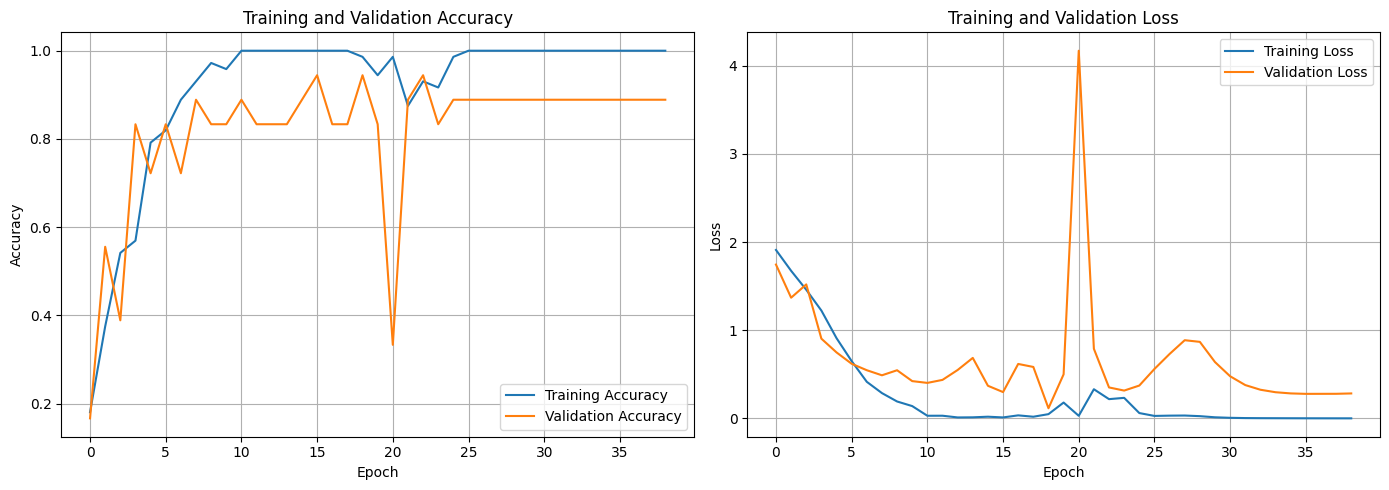

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Task 5: Evaluate the Model

In [12]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)

test_class_names = test_ds.class_names
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.7000 - loss: 0.9792
Test Loss: 0.9792
Test Accuracy: 0.7000


## Task 6: Save and Load the Model

In [13]:
model.save('fruit_classifier_cnn.h5')
print("Model saved successfully as 'fruit_classifier_cnn.h5'")

loaded_model = keras.models.load_model('fruit_classifier_cnn.h5')
print("Model loaded successfully!")

loaded_test_loss, loaded_test_acc = loaded_model.evaluate(test_ds)
print(f"Loaded Model - Test Loss: {loaded_test_loss:.4f}")
print(f"Loaded Model - Test Accuracy: {loaded_test_acc:.4f}")

Model saved successfully as 'fruit_classifier_cnn.h5'


Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step - accuracy: 0.7000 - loss: 0.9792
Loaded Model - Test Loss: 0.9792
Loaded Model - Test Accuracy: 0.7000


## Task 7: Predictions and Classification Report

In [14]:
all_test_images = []
all_test_labels = []

for images, labels in test_ds:
    all_test_images.append(images.numpy())
    all_test_labels.append(labels.numpy())

all_test_images = np.concatenate(all_test_images, axis=0)
all_test_labels = np.concatenate(all_test_labels, axis=0)

predictions = model.predict(all_test_images)
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted labels:", predicted_labels)
print("Actual labels:   ", all_test_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
Predicted labels: [1 1 0 3 0 1 1 1 1 5 2 2 2 1 5 4 5 3 3 3 4 4 4 4 4 5 5 5 5 1]
Actual labels:    [0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3 4 4 4 4 4 5 5 5 5 5]


In [15]:
report = classification_report(
    all_test_labels,
    predicted_labels,
    target_names=test_class_names
)
print(report)

              precision    recall  f1-score   support

        acai       1.00      0.40      0.57         5
     cupuacu       0.50      0.80      0.62         5
    graviola       1.00      0.60      0.75         5
     guarana       0.75      0.60      0.67         5
     pupunha       0.83      1.00      0.91         5
      tucuma       0.57      0.80      0.67         5

    accuracy                           0.70        30
   macro avg       0.78      0.70      0.70        30
weighted avg       0.78      0.70      0.70        30



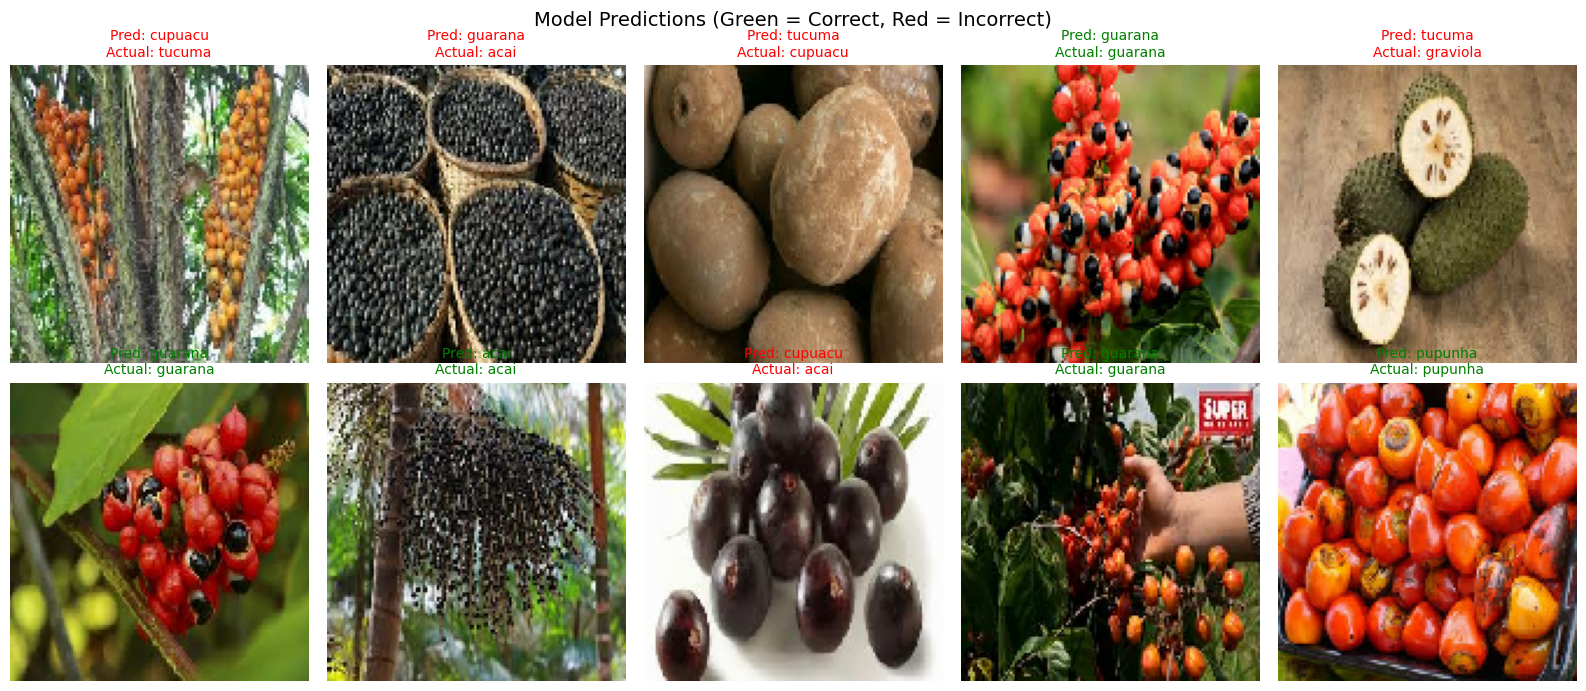

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

indices = random.sample(range(len(all_test_labels)), min(10, len(all_test_labels)))

for i, idx in enumerate(indices):
    axes[i].imshow(all_test_images[idx])
    actual = test_class_names[all_test_labels[idx]]
    predicted = test_class_names[predicted_labels[idx]]
    color = 'green' if actual == predicted else 'red'
    axes[i].set_title(f"Pred: {predicted}\nActual: {actual}", color=color, fontsize=10)
    axes[i].axis('off')

plt.suptitle("Model Predictions (Green = Correct, Red = Incorrect)", fontsize=14)
plt.tight_layout()
plt.show()